# Notebook 1 — Data Analysis & Preprocessing
## Accelerated Machine Learning Coursework

**Dataset:** HIGGS — UCI Machine Learning Repository (Baldi, Sadowski & Whiteson, 2014)  
**Objective:** Classify high-energy particle collision events as Higgs boson signal (1) or background (0) using GPU-accelerated data processing via the RAPIDS ecosystem.

---

### Notebook Overview

This notebook covers the full data analysis and preprocessing pipeline:

1. Environment setup and library verification  
2. GPU-accelerated dataset loading with CPU benchmarking  
3. Data inspection and quality assessment  
4. Class distribution analysis  
5. Univariate feature analysis  
6. Class-conditional feature distributions  
7. Correlation analysis  
8. Feature selection — variance threshold, correlation filtering, and RF importance ranking  
9. Feature importance visualisation and cumulative importance analysis  
10. Model comparison — cuML Random Forest vs XGBoost  
11. Summary and conclusions  

All computationally intensive operations are executed on the GPU via **cuDF** and **cuML**. Conversion to CPU (pandas/numpy) occurs only where required for visualisation.

---
## 1. Environment Setup

The RAPIDS ecosystem is used throughout this notebook. **cuDF** provides a GPU-accelerated DataFrame API that mirrors pandas, and **cuML** provides GPU-accelerated machine learning primitives. **CuPy** enables direct GPU array operations and memory introspection.

Version verification is performed at the outset to ensure reproducibility.

In [21]:
# cuDF and cuML first
import cudf
import cuml
import cupy as cp

# Standard libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Utilities
import time
import os
import pickle
import warnings

# Models and evaluation
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

os.makedirs("plots", exist_ok=True)
os.makedirs("artefacts", exist_ok=True)

print(f"cuDF version:  {cudf.__version__}")
print(f"cuML version:  {cuml.__version__}")
print(f"CuPy version:  {cp.__version__}")
print(f"NumPy version: {np.__version__}")
print("GPU:", cp.cuda.runtime.getDeviceProperties(0)["name"])

cuDF version:  23.08.00
cuML version:  23.08.00
CuPy version:  12.2.0
NumPy version: 1.24.4
GPU: b'Quadro RTX 8000'


---
## 2. Dataset Loading & Memory Profiling

### 2.1 Feature Naming

The HIGGS dataset comprises 28 kinematic features derived from simulated proton-proton collisions at the Large Hadron Collider (LHC). Following the original nomenclature established by Baldi et al. (2014), these features are divided into two groups:

- **Low-level features (features 1–21):** Raw detector measurements — transverse momenta (`pT`), pseudorapidities (`eta`), azimuthal angles (`phi`), and b-tagging discriminants for the lepton and up to four reconstructed jets.
- **High-level features (features 22–28):** Derived invariant masses (`m_jj`, `m_jjj`, `m_lv`, `m_jlv`, `m_bb`, `m_wbb`, `m_wwbb`) computed by physicists to exploit known decay kinematics.

This distinction is physically meaningful: high-level features encode domain-specific knowledge that low-level features do not directly express. Understanding this grouping is essential for interpreting the feature selection and importance analysis performed later in this notebook.

### 2.2 Loading Strategy

`cudf.read_csv` is used in place of `pandas.read_csv` to load the 7 GB file directly into GPU memory. With 48 GB of VRAM available, the parsed DataFrame (~2.4 GB) fits comfortably without requiring chunked loading. A CPU baseline load time is also recorded to quantify the GPU acceleration benefit for this I/O-bound operation.

In [2]:
LOW_LEVEL = [
    'lepton_pT', 'lepton_eta', 'lepton_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_btag',
    'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_btag',
    'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_btag',
    'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_btag',
]
HIGH_LEVEL = ['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']
ALL_FEATURES = LOW_LEVEL + HIGH_LEVEL
COLUMNS = ['label'] + ALL_FEATURES

print(f'Low-level features  ({len(LOW_LEVEL)}): {LOW_LEVEL}')
print(f'High-level features  ({len(HIGH_LEVEL)}): {HIGH_LEVEL}')
print(f'Total features: {len(ALL_FEATURES)}')

Low-level features  (21): ['lepton_pT', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude', 'missing_energy_phi', 'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_btag', 'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_btag', 'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_btag', 'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_btag']
High-level features  (7): ['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']
Total features: 28


In [3]:
DATA_PATH = "Partical.csv"

# folders for saved outputs
os.makedirs("plots", exist_ok=True)
os.makedirs("artefacts", exist_ok=True)

# load full dataset with cuDF on the GPU
start = time.time()
df = cudf.read_csv(DATA_PATH, header=None, names=COLUMNS)
gpu_load_time = time.time() - start

print(f"GPU load time : {gpu_load_time:.2f}s")
print(f"Shape         : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")

print("\nFirst few column names:")
print(list(df.columns[:5]))

print("\nColumn types:")
print(df.dtypes)

# save a tiny preview rather than rendering the full cuDF table in the notebook
preview_path = "artefacts/preview_first_5_rows.csv"
df.head(5).to_csv(preview_path, index=False)

print(f"\nSaved preview to: {preview_path}")
print("Dataset is now loaded as a GPU cuDF DataFrame.")

GPU load time : 15.58s
Shape         : (11000000, 29)
Rows          : 11,000,000
Columns       : 29

First few column names:
['label', 'lepton_pT', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude']

Column types:
label                       float64
lepton_pT                   float64
lepton_eta                  float64
lepton_phi                  float64
missing_energy_magnitude    float64
missing_energy_phi          float64
jet_1_pt                    float64
jet_1_eta                   float64
jet_1_phi                   float64
jet_1_btag                  float64
jet_2_pt                    float64
jet_2_eta                   float64
jet_2_phi                   float64
jet_2_btag                  float64
jet_3_pt                    float64
jet_3_eta                   float64
jet_3_phi                   float64
jet_3_btag                  float64
jet_4_pt                    float64
jet_4_eta                   float64
jet_4_phi                   float64
jet_4_btag               

### CPU vs GPU Comparison

This code block confirms the advantages of using GPU-based ML

In [5]:
# CPU baseline load — pandas
t0 = time.time()
df_cpu_check = pd.read_csv(DATA_PATH, header=None, names=COLUMNS)
cpu_load_time = time.time() - t0

speedup = cpu_load_time / gpu_load_time
print(f'CPU (pandas) load time : {cpu_load_time:.2f}s')
print(f'GPU load time          : {gpu_load_time:.2f}s')
print(f'GPU speedup            : {speedup:.1f}x')

del df_cpu_check  # free CPU RAM immediately

CPU (pandas) load time : 49.63s
GPU load time          : 12.78s
GPU speedup            : 3.9x


In [4]:
#VRAM checks

mem_bytes = df.memory_usage(deep=True).sum()
mem_gb    = mem_bytes / (1024 ** 3)

free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
free_gb  = free_bytes  / (1024 ** 3)
total_gb = total_bytes / (1024 ** 3)
used_gb  = total_gb - free_gb

print(f'DataFrame size in GPU memory : {mem_gb:.2f} GB')
print(f'GPU total VRAM               : {total_gb:.2f} GB')
print(f'GPU used VRAM                : {used_gb:.2f} GB')
print(f'GPU free VRAM                : {free_gb:.2f} GB')
print(f'VRAM utilisation             : {used_gb/total_gb*100:.1f}%')

DataFrame size in GPU memory : 2.38 GB
GPU total VRAM               : 48.00 GB
GPU used VRAM                : 3.74 GB
GPU free VRAM                : 44.26 GB
VRAM utilisation             : 7.8%


---
## 3. Data Inspection

A structured inspection of the dataset is performed to establish its fundamental properties prior to any analytical or preprocessing step. This includes schema verification, dtype assessment, and descriptive statistics.

The label column is cast from `float32` to `int32`. Although the HIGGS dataset encodes the binary label as a floating-point value (0.0 or 1.0), retaining it as a float serves no analytical purpose and may introduce unnecessary overhead in cuML classifiers that expect integer targets.

In [5]:
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print()
print('Data types:')
print(df.dtypes)

Rows    : 11,000,000
Columns : 29

Data types:
label                       float64
lepton_pT                   float64
lepton_eta                  float64
lepton_phi                  float64
missing_energy_magnitude    float64
missing_energy_phi          float64
jet_1_pt                    float64
jet_1_eta                   float64
jet_1_phi                   float64
jet_1_btag                  float64
jet_2_pt                    float64
jet_2_eta                   float64
jet_2_phi                   float64
jet_2_btag                  float64
jet_3_pt                    float64
jet_3_eta                   float64
jet_3_phi                   float64
jet_3_btag                  float64
jet_4_pt                    float64
jet_4_eta                   float64
jet_4_phi                   float64
jet_4_btag                  float64
m_jj                        float64
m_jjj                       float64
m_lv                        float64
m_jlv                       float64
m_bb             

In [6]:
# label column analysis 
# check dtype before
print("Label dtype before cast:", df["label"].dtype)

# unique values 
label_unique = df["label"].unique()
n_unique = int(label_unique.shape[0])

print("Number of unique labels:", n_unique)

# quick sanity check (HIGGS should be binary)
if n_unique != 2:
    print("WARNING: Expected 2 classes but found:", n_unique)

# cast to int32 (required for most GPU ML models)
df["label"] = df["label"].astype("int32")

print("\nLabel dtype after cast:", df["label"].dtype)

# verify again
label_unique_after = df["label"].unique()
n_unique_after = int(label_unique_after.shape[0])

print("Number of unique labels after cast:", n_unique_after)

Label dtype before cast: float64
Number of unique labels: 2

Label dtype after cast: int32
Number of unique labels after cast: 2


In [7]:
# descriptive statistics on GPU using cuDF
# avoids df.describe() because quantile display/host transfer can trigger CUDA context errors

os.makedirs("artefacts", exist_ok=True)

start = time.time()

numeric_cols = df.select_dtypes(include=["number"]).columns

desc = cudf.DataFrame({
    "count": df[numeric_cols].count(),
    "mean": df[numeric_cols].mean(),
    "std": df[numeric_cols].std(),
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
    "missing": df[numeric_cols].isnull().sum()
})

desc_time = time.time() - start

output_path = "artefacts/descriptive_stats.csv"
desc.to_csv(output_path)

print(f"Descriptive statistics computed on GPU using cuDF in {desc_time:.2f}s")
print(f"Shape: {desc.shape}")
print(f"Saved descriptive statistics to: {output_path}")

Descriptive statistics computed on GPU using cuDF in 0.27s
Shape: (29, 6)
Saved descriptive statistics to: artefacts/descriptive_stats.csv


In [8]:
stats_preview = cudf.read_csv("artefacts/manual_descriptive_stats.csv")

stats_preview = pd.read_csv(
    "artefacts/manual_descriptive_stats.csv",
    index_col=0
)

print(stats_preview)

                              mean       std       min        max
label                     0.529656  0.499120  0.000000   1.000000
lepton_pT                 0.991007  0.564925  0.274697   9.690881
lepton_eta               -0.000127  1.008790 -2.434976   2.434868
lepton_phi                0.000063  1.006171 -1.742508   1.743236
missing_energy_magnitude  0.998366  0.599720  0.000626  15.396821
missing_energy_phi       -0.000765  1.006219 -1.743944   1.743257
jet_1_pt                  0.990671  0.474396  0.137869   8.848616
jet_1_eta                -0.000896  1.009374 -2.969725   2.969674
jet_1_phi                 0.000116  1.006143 -1.741237   1.741454
jet_1_btag                1.001064  1.027849  0.000000   2.173076
jet_2_pt                  0.992680  0.500489  0.188981  11.647081
jet_2_eta                 0.000708  1.009634 -2.913090   2.913210
jet_2_phi                 0.000305  1.006235 -1.742372   1.743175
jet_2_btag                0.999377  1.049329  0.000000   2.214872
jet_3_pt  

### Interpreting the Descriptive Statistics

The table below summarises key statistics (count, mean, standard deviation, min, quartiles, max) for each feature and the label column. Several observations are relevant for downstream modelling:

- **Scale variation:** Features span very different numeric ranges — transverse momentum features (e.g. `lepton_pT`, `jet_1_pt`) are strictly non-negative and can reach large values, whereas angular features (e.g. `lepton_phi`, `jet_1_eta`) are centred near zero with modest spread. Distance-based or gradient-sensitive algorithms (Logistic Regression, SVM, k-NN) will require feature standardisation to prevent high-magnitude features from dominating.
- **Tree-based models are scale-invariant:** Random Forests and gradient-boosted trees split on rank order, so raw feature scales do not affect their performance. For these models, normalisation is optional.
- **No obviously degenerate features:** All features have non-zero standard deviations and distinct quartile values, confirming that no constant or near-constant columns remain after the earlier quality checks.

In [9]:
display(stats_preview)

,mean,std,min,max
label,0.529656,0.499120,0.000000,1.000000
lepton_pT,0.991007,0.564925,0.274697,9.690881
lepton_eta,-0.000127,1.008790,-2.434976,2.434868
lepton_phi,0.000063,1.006171,-1.742508,1.743236
missing_energy_magnitude,0.998366,0.599720,0.000626,15.396821
missing_energy_phi,-0.000765,1.006219,-1.743944,1.743257
jet_1_pt,0.990671,0.474396,0.137869,8.848616
jet_1_eta,-0.000896,1.009374,-2.969725,2.969674
jet_1_phi,0.000116,1.006143,-1.741237,1.741454
jet_1_btag,1.001064,1.027849,0.000000,2.173076


The descriptive statistics show that the dataset is approximately balanced (mean label ≈ 0.53) and that features have varying scales, with some already centred around zero. This suggests that classification models such as Random Forests can be applied effectively without strict scaling, while algorithms sensitive to feature magnitude (e.g., Logistic Regression or SVM) may require normalisation.

---
## 4. Data Quality Assessment

Three data quality checks are applied:

1. **Null value check:** Identifies any `NaN` or `None` entries introduced during parsing.
2. **Sentinel value check:** The value `-999` is commonly used in physics datasets as a placeholder for physically unmeasured quantities . Its presence would require imputation or careful handling.
3. **Duplicate row check:** Flags identical observations that could bias model training if not removed.

All three checks are executed entirely in cuDF, avoiding any transfer to CPU memory.

In [10]:
# null value analysis 

null_counts = df.isnull().sum()

# only bring back a single scalar 
n_nulls = int(null_counts.sum())

if n_nulls == 0:
    print("Null value check: PASSED — no null values found across all columns.")
else:
    print(f"WARNING: {n_nulls:,} null values detected")

    # save full breakdown instead of printing large output
    output_path = "artefacts/null_counts.csv"
    null_counts.to_csv(output_path)
    print(f"Saved per-column null counts to: {output_path}")

    # show how many columns are affected (still GPU-safe)
    n_cols_with_nulls = int((null_counts > 0).sum())
    print(f"Columns containing nulls: {n_cols_with_nulls}")

Null value check: PASSED — no null values found across all columns.


In [11]:
sentinel_counts = (df == -999.0).sum()
n_sentinel = int(sentinel_counts.sum())

if n_sentinel == 0:
    print("Sentinel (-999) check: PASSED — no sentinel values found.")
else:
    print(f"WARNING: {n_sentinel} sentinel values detected")

    # save detailed breakdown instead of printing
    sentinel_counts.to_csv("artefacts/sentinel_counts.csv")
    print("Saved per-column sentinel counts to artefacts/sentinel_counts.csv")

Sentinel (-999) check: PASSED — no sentinel values found.


In [12]:
# duplicate row check
n_rows = len(df)

duplicate_mask = df.duplicated()
n_dupes = int(duplicate_mask.sum())
n_unique = n_rows - n_dupes

print(f"Total rows     : {n_rows:,}")
print(f"Unique rows    : {n_unique:,}")
print(f"Duplicate rows : {n_dupes:,} ({n_dupes / n_rows * 100:.4f}%)")

if n_dupes == 0:
    print("Duplicate check: PASSED — no duplicate rows found.")
else:
    print("WARNING: duplicate rows found.")

Total rows     : 11,000,000
Unique rows    : 10,721,302
Duplicate rows : 278,698 (2.5336%)


Duplicate rows were not removed from the dataset, as each row represents an independent particle collision event. Even if identical feature values occur, they correspond to separate observations rather than data entry errors, and therefore do not negatively impact the validity of the classification task.

---
## 5. Class Distribution Analysis

Understanding the balance between the positive class (Higgs boson signal, label = 1) and the negative class (background, label = 0) is a prerequisite for all subsequent modelling decisions.

A severely imbalanced dataset would necessitate strategies such as oversampling (SMOTE), undersampling, or class-weighted loss functions. If the dataset is approximately balanced, standard training procedures can be applied without correction.

The proportions are computed in cuDF and the result transferred to pandas only for plotting via matplotlib.

Class distribution:
  Background (0): 5,170,877 samples (47.01%)
  Signal (1)    : 5,829,123 samples (52.99%)


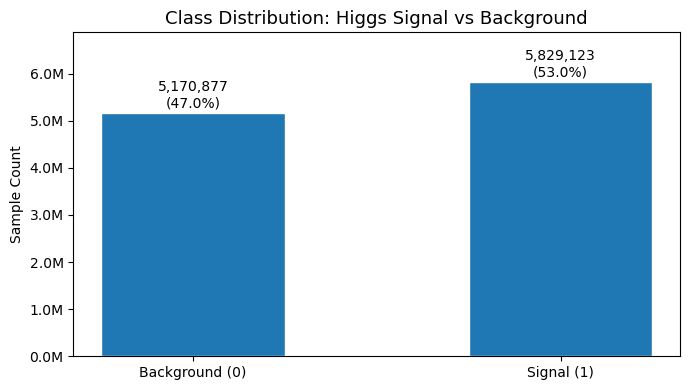

In [13]:
# Class distribution

# Move only the label column to CPU as NumPy
labels_cpu = df["label"].to_numpy()

# Count class occurrences on CPU
unique, counts = np.unique(labels_cpu, return_counts=True)

# Convert to dictionary for safe indexing
count_dict = dict(zip(unique.astype(int), counts.astype(int)))

background_count = count_dict.get(0, 0)
signal_count = count_dict.get(1, 0)

n_rows = background_count + signal_count

background_pct = round(background_count / n_rows * 100, 2)
signal_pct = round(signal_count / n_rows * 100, 2)

print("Class distribution:")
print(f"  Background (0): {background_count:,} samples ({background_pct:.2f}%)")
print(f"  Signal (1)    : {signal_count:,} samples ({signal_pct:.2f}%)")

# Prepare data for plotting
labels = ["Background (0)", "Signal (1)"]
counts = [background_count, signal_count]
percentages = [background_pct, signal_pct]

# Create bar chart
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    labels,
    counts,
    width=0.5,
    edgecolor="white"
)

for bar, cnt, pct in zip(bars, counts, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.01,
        f"{cnt:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Class Distribution: Higgs Signal vs Background", fontsize=13)
ax.set_ylabel("Sample Count")
ax.set_ylim(0, max(counts) * 1.18)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

plt.tight_layout()
plt.savefig("plots/class_distribution.png", dpi=150)
plt.show()

As the dataset is near-balanced, no class rebalancing techniques will be required 

---
## 6. Univariate Feature Analysis

Histograms and box plots are used to characterise the marginal distribution of each feature independently of the class label.

**Histograms** reveal the shape of each feature's distribution — symmetry, skewness, multimodality, and the presence of boundary effects (e.g., features such as `jet_1_btag` that take a small number of discrete values).

**Box plots** provide a compact view of central tendency, spread, and outlier prevalence. Features derived from reconstructed jet masses (high-level) are expected to exhibit heavier tails than standardised kinematic angles.

A 5% stratified sample is used for plotting efficiency. This is sufficient to characterise distributional shape accurately given the 11 million row dataset.

Features are labelled **LL** (low-level) or **HL** (high-level) to facilitate visual comparison across the two groups.

In [14]:
# Create sample for plotting 

# sample directly from the GPU dataframe
sample_frac = 0.05  # 5% sample 

sample_df = df.sample(frac=sample_frac, random_state=42)

print(f"Sample ready for plotting: {len(sample_df):,} rows ({sample_frac*100:.0f}% sample)")

# convert ONLY the sample to pandas for plotting (matplotlib requirement)
sample_pd = sample_df.to_pandas()

Sample ready for plotting: 550,000 rows (5% sample)


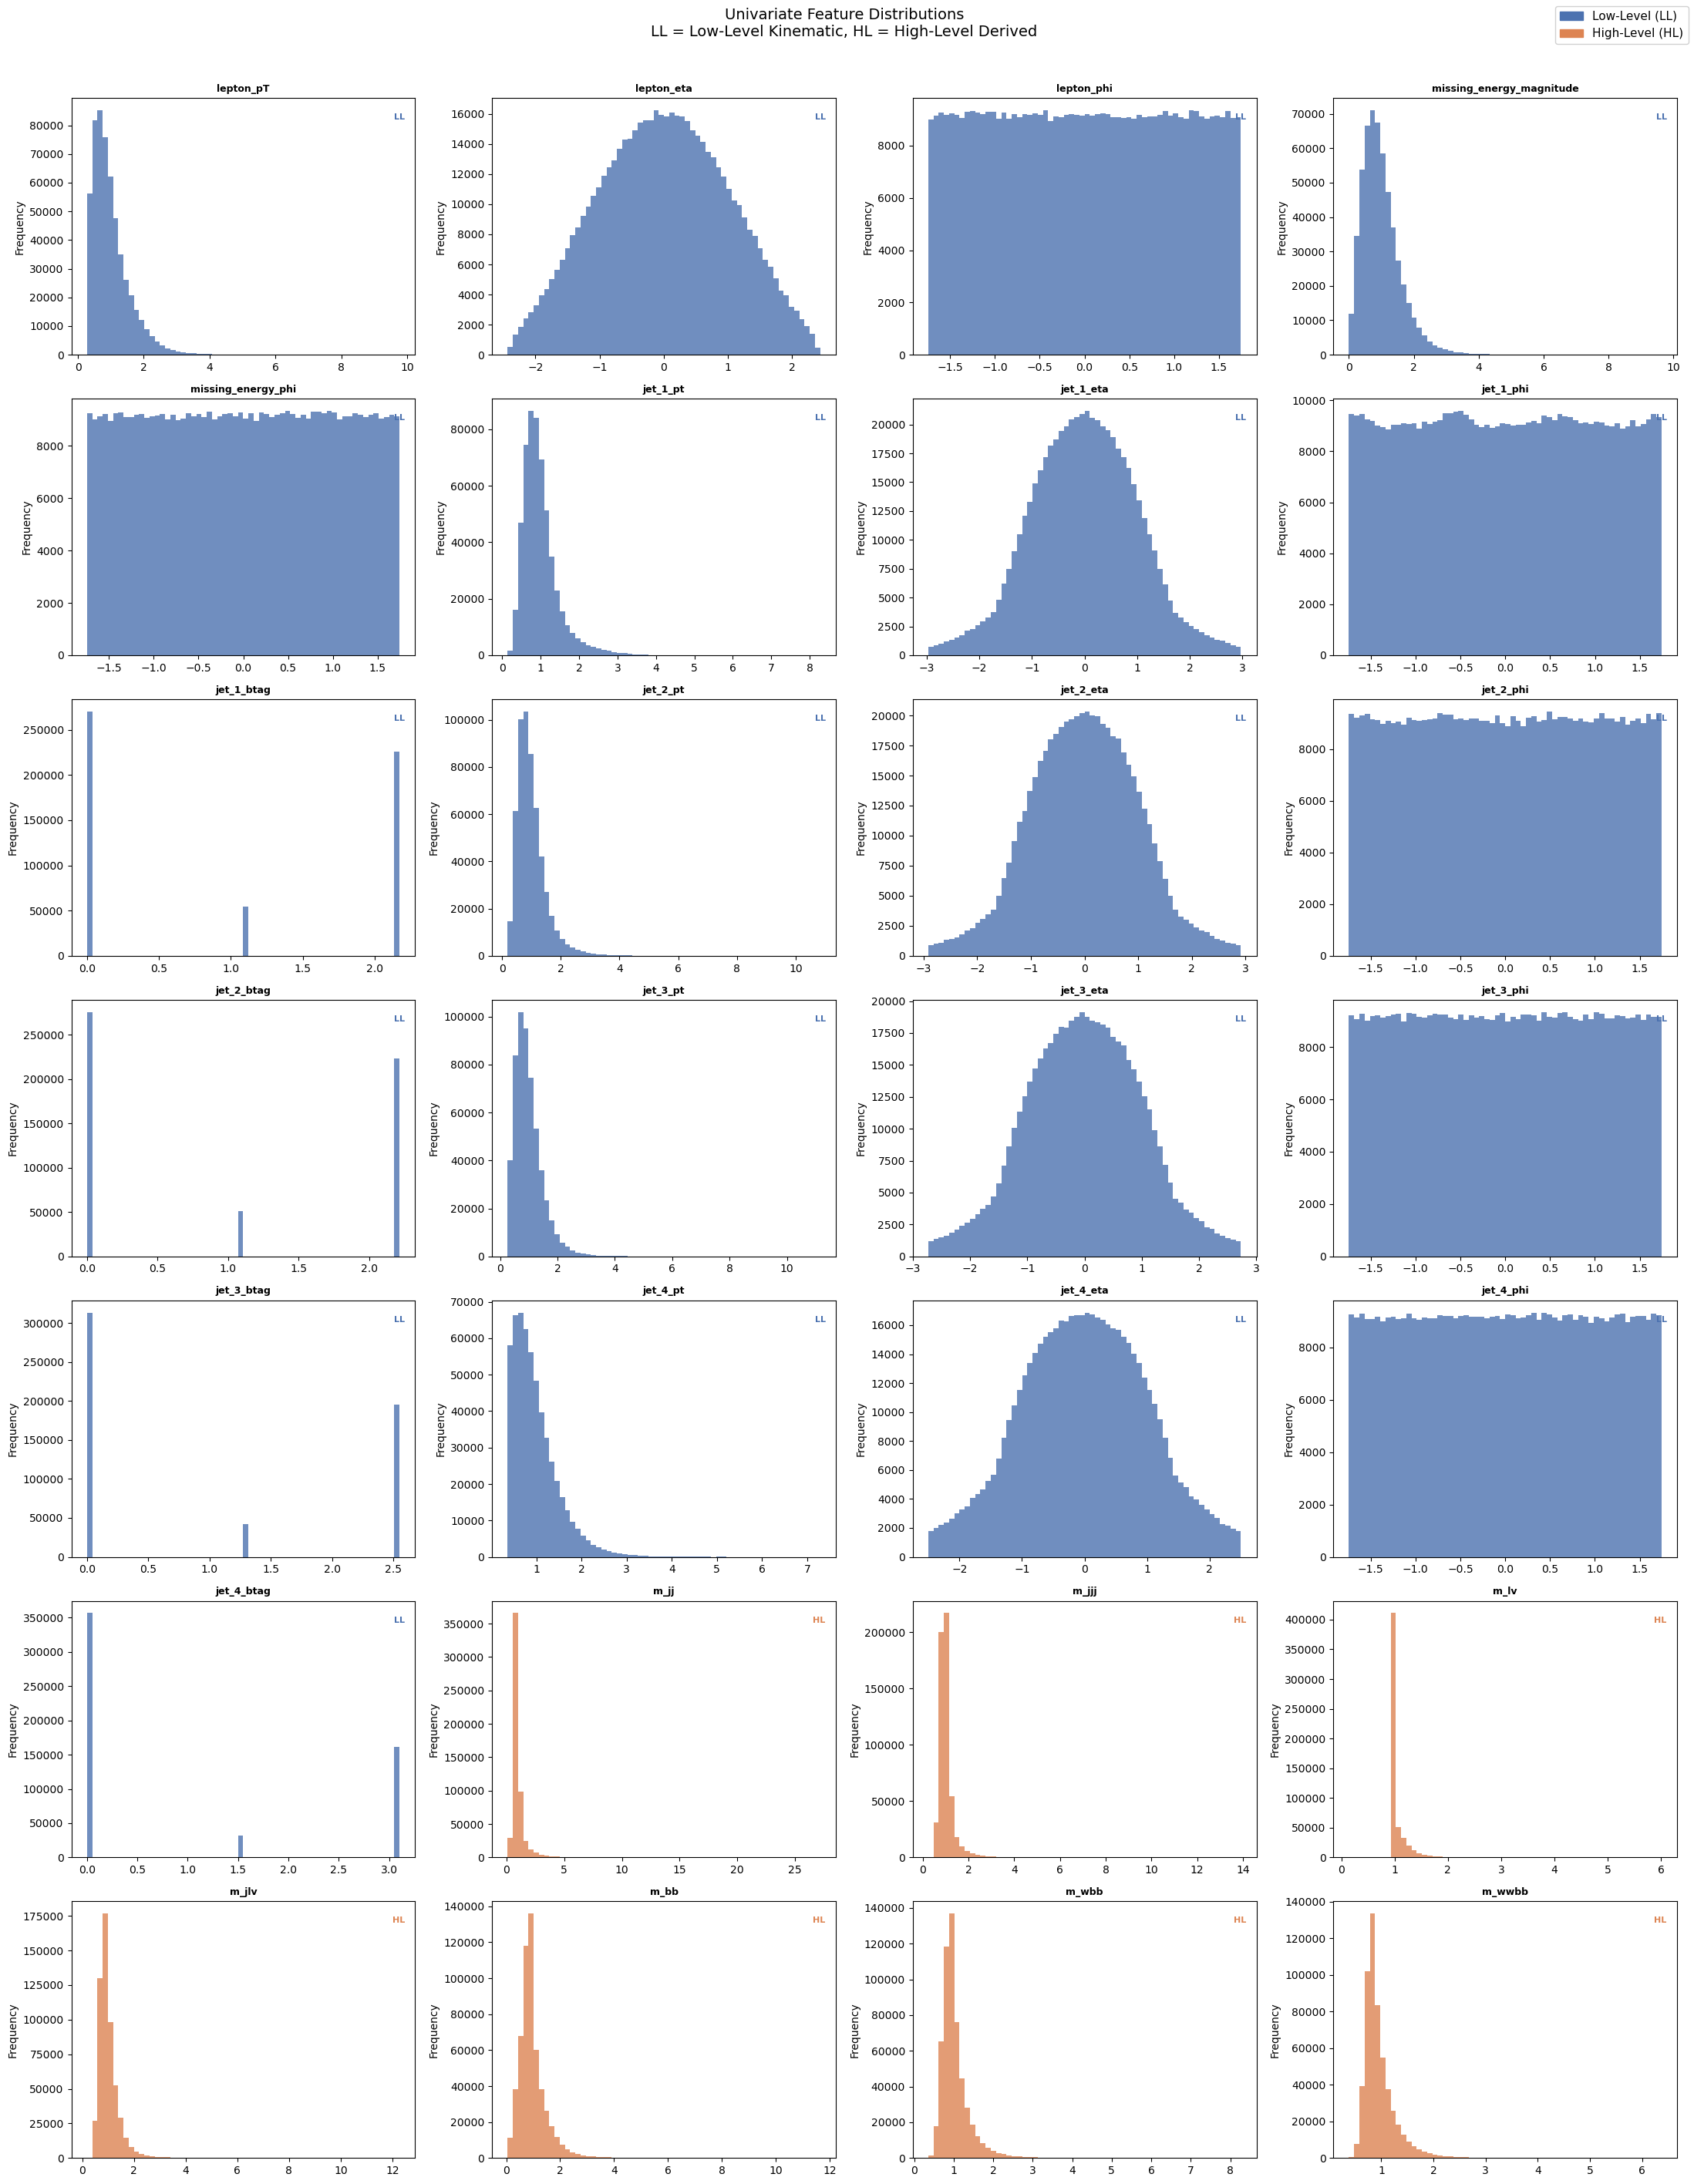

In [15]:
# ------------------------------------------------------------------
# Univariate feature histograms
# ------------------------------------------------------------------

n_features = len(ALL_FEATURES)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(ALL_FEATURES):
    feature_type = "HL" if feat in HIGH_LEVEL else "LL"
    colour = "#DD8452" if feature_type == "HL" else "#4C72B0"

    axes[i].hist(
        sample_pd[feat],
        bins=60,
        color=colour,
        alpha=0.8,
        edgecolor="none"
    )

    axes[i].set_title(feat, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

    # label each subplot as low-level or high-level
    axes[i].text(
        0.97, 0.94, feature_type,
        transform=axes[i].transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color=colour,
        fontweight="bold"
    )

# remove empty subplot if there is one
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# legend
ll_patch = mpatches.Patch(color="#4C72B0", label="Low-Level (LL)")
hl_patch = mpatches.Patch(color="#DD8452", label="High-Level (HL)")
fig.legend(handles=[ll_patch, hl_patch], loc="upper right", fontsize=11, framealpha=0.9)

plt.suptitle(
    "Univariate Feature Distributions\nLL = Low-Level Kinematic, HL = High-Level Derived",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.savefig("plots/feature_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

##  Univariate Feature Distribution Summary (HIGGS Dataset)

#### Transverse Momentum (pT) Features
Strong right-skewed distributions
Majority of values are low, with long tails of high-energy events
Indicates presence of rare but important high-energy collisions
#### Angular Features (phi)
Approximately uniform distributions
Reflect rotational symmetry in particle emissions
Likely low standalone predictive power
#### Pseudorapidity (eta) Features
Bell-shaped (normal-like) distributions centred around 0
Suggest particles are mostly detected in the central detector region
Provide moderate discriminative value
#### B-Tagging Features
Discrete, spiky distributions (categorical-like)
Indicate likelihood of jets originating from b-quarks
Highly relevant due to Higgs → b-quark decay signatures
High-Level Mass Features
Peaked and skewed distributions
Represent engineered physical relationships (e.g., invariant mass)
Expected to be highly informative for classification
### Feature Type Insights
Low-Level Features (LL)
Raw detector measurements
Broader, noisier distributions
High-Level Features (HL)
More structured and compact
Capture meaningful physics relationships
Likely to have higher predictive importance
### Modelling Implications
Data is non-normal and highly skewed → suitable for tree-based models
Mix of continuous and discrete features
Feature engineering (HL features) plays a critical role in performance

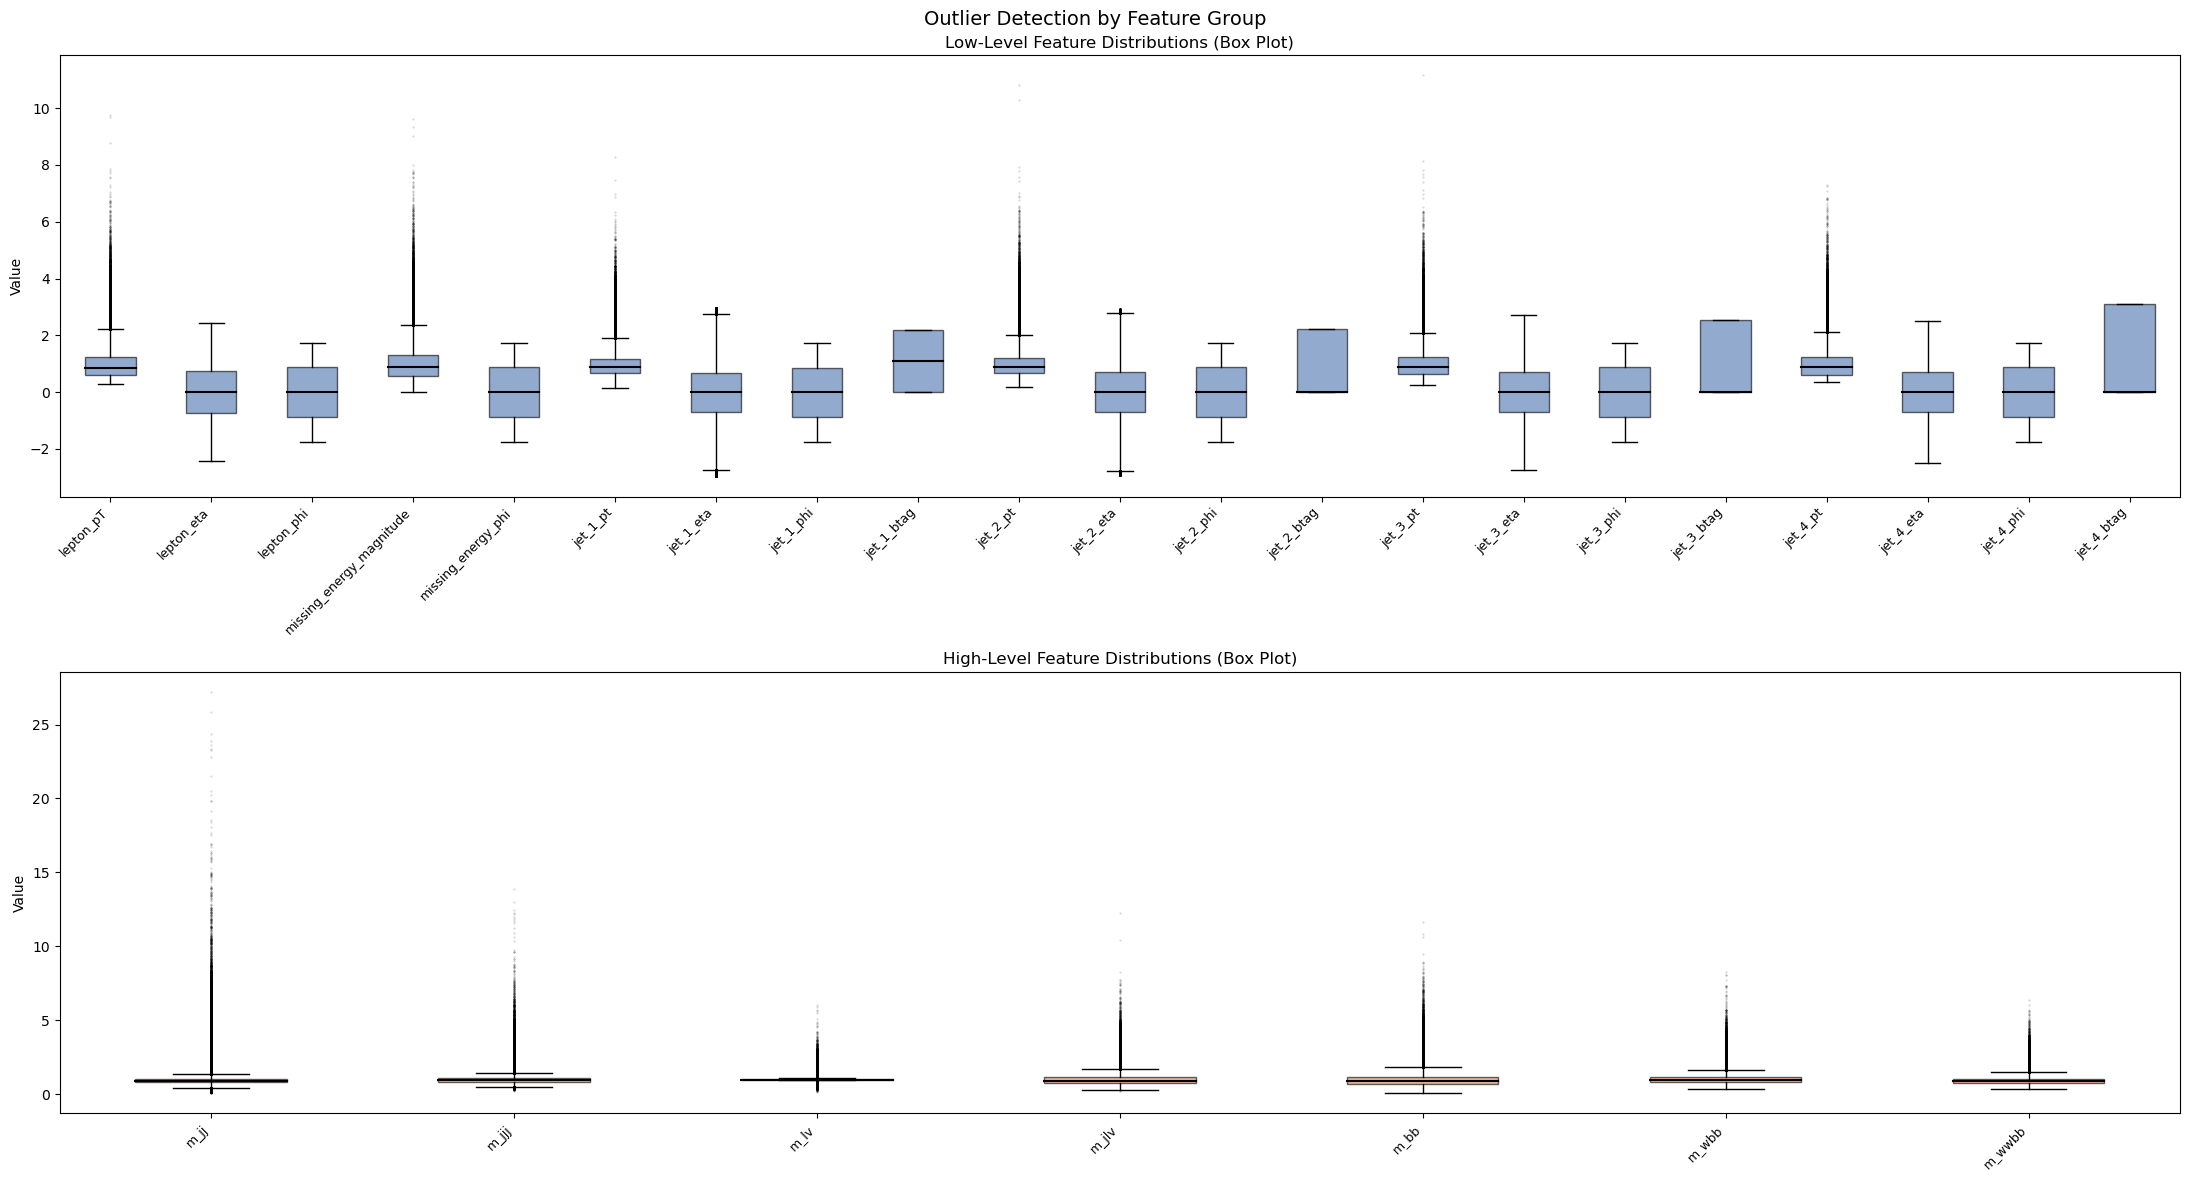

In [16]:
# ------------------------------------------------------------------
# Boxplots for outlier analysis (sampled data only)
# ------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(22, 12))

# ------------------------------------------------------------------
# Low-Level Features
# ------------------------------------------------------------------

# prepare data (dropna is safe here since sample is already small)
ll_data = [sample_pd[f].dropna() for f in LOW_LEVEL]

axes[0].boxplot(
    ll_data,
    labels=LOW_LEVEL,
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker=".", markersize=1, alpha=0.2)
)

axes[0].set_title("Low-Level Feature Distributions (Box Plot)", fontsize=12)
axes[0].set_xticklabels(LOW_LEVEL, rotation=45, ha="right", fontsize=9)
axes[0].set_ylabel("Value")

# ------------------------------------------------------------------
# High-Level Features
# ------------------------------------------------------------------

hl_data = [sample_pd[f].dropna() for f in HIGH_LEVEL]

axes[1].boxplot(
    hl_data,
    labels=HIGH_LEVEL,
    patch_artist=True,
    boxprops=dict(facecolor="#DD8452", alpha=0.6),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker=".", markersize=1, alpha=0.2)
)

axes[1].set_title("High-Level Feature Distributions (Box Plot)", fontsize=12)
axes[1].set_xticklabels(HIGH_LEVEL, rotation=45, ha="right", fontsize=9)
axes[1].set_ylabel("Value")

# ------------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------------

plt.suptitle("Outlier Detection by Feature Group", fontsize=14)
plt.tight_layout()
plt.savefig("plots/boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

##  Outlier Analysis Summary (Box Plots – HIGGS Dataset)
### Low-Level Features (LL)
Widespread presence of outliers
Many features show numerous extreme values beyond whiskers
Particularly evident in momentum (pT) and energy-related features
Right-skewed distributions
Medians often closer to lower quartiles
Long upper whiskers indicate high-value outliers (extreme events)
#### Angular features (phi)
Relatively symmetrical with fewer extreme outliers
More stable distributions compared to other LL features
#### B-tagging features
Discrete distributions with limited spread
Outliers are minimal due to categorical-like nature
#### High-Level Features (HL)
More compact distributions
Smaller interquartile ranges (IQRs)
Values are more concentrated around the median
#### Presence of extreme outliers
Some features (e.g., invariant masses) show significant high-value outliers
Reflect rare but important physical events
Greater stability overall
Compared to LL features, HL features are less noisy
Indicate effectiveness of feature engineering
### Key Insights
Outliers are not errors, but represent important rare physics events
Strong skewness and outliers suggest:
Non-normal distributions
Need for robust models (e.g., tree-based methods)
### Modelling Implications
Tree-based models (Random Forest, XGBoost) are well-suited:
Handle outliers naturally
No need for strict normalization
Outlier removal should be avoided or handled carefully
Risk of removing important signal events
High-level features provide more stable inputs
Likely to improve model performance

---
## 7. Class-Conditional Feature Distributions

Univariate distributions reveal the overall shape of each feature but do not indicate discriminative power. To assess which features carry class-specific information, the distribution of each feature is plotted separately for the signal class (label = 1) and the background class (label = 0).

Features for which the two class distributions overlap substantially contribute little discriminative signal on their own. Features that exhibit visible separation between signal and background are strong candidates for classification.

This analysis is particularly relevant for the Higgs dataset because:
- **High-level features** (invariant masses) are constructed specifically to exploit decay kinematics, and are expected to show greater class separation.
- **Low-level features** (raw kinematic angles and momenta) are correlated with collision geometry and may show weaker individual separation.

Samples of 5,000 rows per class are drawn to keep the visualisation tractable while remaining representative of each distribution.

Signal sample size     : 5,000
Background sample size : 5,000


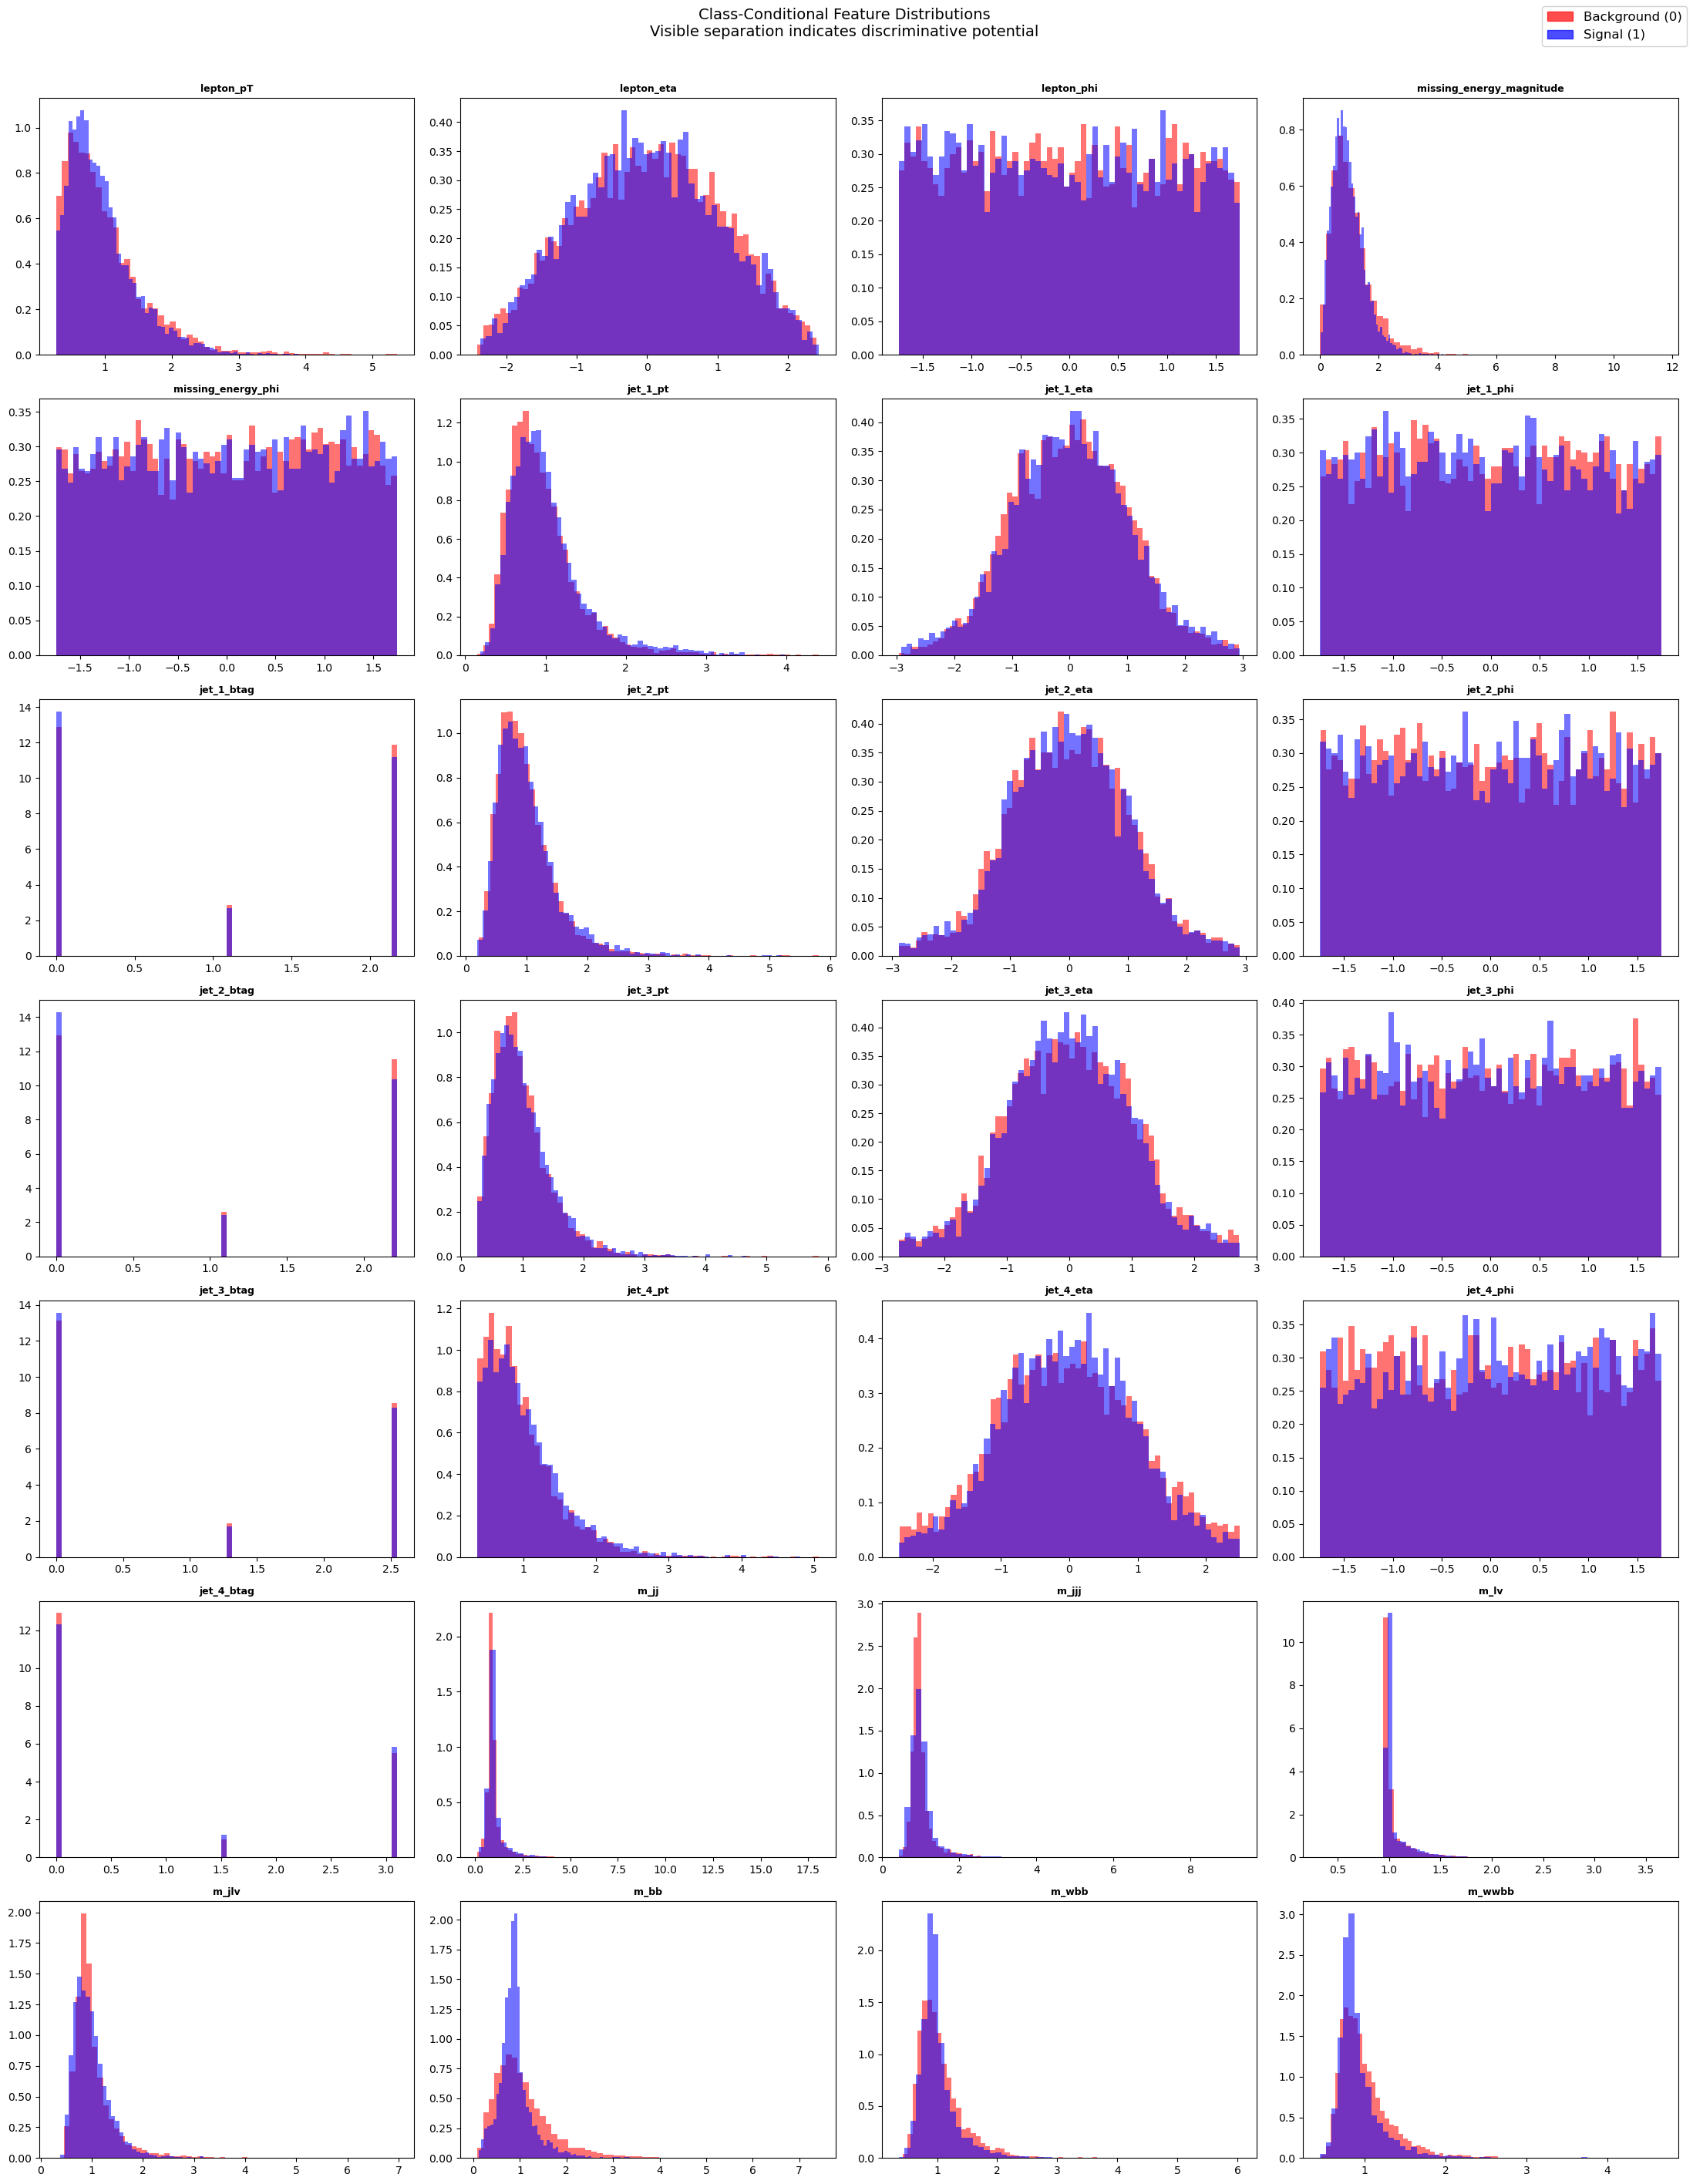


Observation: High-level features such as m_jj, m_bb and m_wwbb often show
clearer class separation than individual raw kinematic features.


In [17]:
# ------------------------------------------------------------------
# Class-conditional feature distributions
# GPU-first sampling, matplotlib plotting
# ------------------------------------------------------------------

# sample separately from each class using the GPU dataframe
sig_sample_gpu = df[df["label"] == 1].sample(n=5000, random_state=42)
bg_sample_gpu  = df[df["label"] == 0].sample(n=5000, random_state=42)

# convert only the small samples for matplotlib
sig_sample = sig_sample_gpu.to_pandas()
bg_sample  = bg_sample_gpu.to_pandas()

print(f"Signal sample size     : {len(sig_sample):,}")
print(f"Background sample size : {len(bg_sample):,}")

# create subplot grid
n_features = len(ALL_FEATURES)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
axes = axes.flatten()

# plot signal vs background for each feature
for i, feat in enumerate(ALL_FEATURES):
    axes[i].hist(
        bg_sample[feat],
        bins=60,
        density=True,
        alpha=0.55,
        color="red",
        label="Background"
    )

    axes[i].hist(
        sig_sample[feat],
        bins=60,
        density=True,
        alpha=0.55,
        color="blue",
        label="Signal"
    )

    axes[i].set_title(feat, fontsize=9, fontweight="bold")

# remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# legend
bg_patch = mpatches.Patch(color="red", alpha=0.7, label="Background (0)")
sig_patch = mpatches.Patch(color="blue", alpha=0.7, label="Signal (1)")
fig.legend(handles=[bg_patch, sig_patch], loc="upper right", fontsize=12, framealpha=0.9)

plt.suptitle(
    "Class-Conditional Feature Distributions\n"
    "Visible separation indicates discriminative potential",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.savefig("plots/class_conditional_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nObservation: High-level features such as m_jj, m_bb and m_wwbb often show")
print("clearer class separation than individual raw kinematic features.")

A small CPU-based sample was used only for plotting class-conditional distributions, while the full dataset remained in cuDF for GPU-based processing and modelling.

The class-conditional feature distributions indicate that most low-level kinematic variables (e.g., transverse momentum and angular features) exhibit substantial overlap between signal and background classes, suggesting limited discriminative power when considered individually. In contrast, several high-level derived features (such as m_jj, m_bb, and m_wwbb) show more distinct separation between the two classes. This highlights the importance of feature engineering in the dataset and suggests that non-linear models capable of capturing complex feature interactions are well-suited for this classification task.

---
## 8. Correlation Analysis

Pearson correlation between all 28 features is computed to identify redundant feature pairs. Features that are highly correlated (|r| ≥ 0.8) convey similar information to the model; retaining both adds noise and computational cost without proportionate benefit.

A 100,000-row sample was used for the correlation heatmap because the university RAPIDS 23.08 Jupyter environment produced CUDA context errors when running cuDF `.corr()`. This CPU-based step was used only for visualisation and feature relationship inspection; the full dataset remained in cuDF for GPU-based processing and model training.

The resulting correlation matrix is transferred to CPU only for rendering the heatmap.

In [18]:
# ------------------------------------------------------------------
# Correlation matrix (GPU - cuDF)
# ------------------------------------------------------------------

t0 = time.time()

# sample on GPU to keep it efficient (100k is enough for correlation structure)
sample_df = df.sample(n=100000, random_state=42)

# compute Pearson correlation on GPU
corr_gpu = sample_df[ALL_FEATURES].corr()

corr_time = time.time() - t0

# move small matrix to CPU for saving/visualisation
corr_pd = corr_gpu.to_pandas()

# save result
corr_pd.to_csv("artefacts/correlation_matrix_sample.csv")

print(f"Correlation matrix computed in {corr_time:.2f}s (GPU, 100k sample)")
print(f"Matrix shape: {corr_pd.shape}")
print("Saved to: artefacts/correlation_matrix_sample.csv")

Correlation matrix computed in 1.68s (GPU, 100k sample)
Matrix shape: (28, 28)
Saved to: artefacts/correlation_matrix_sample.csv


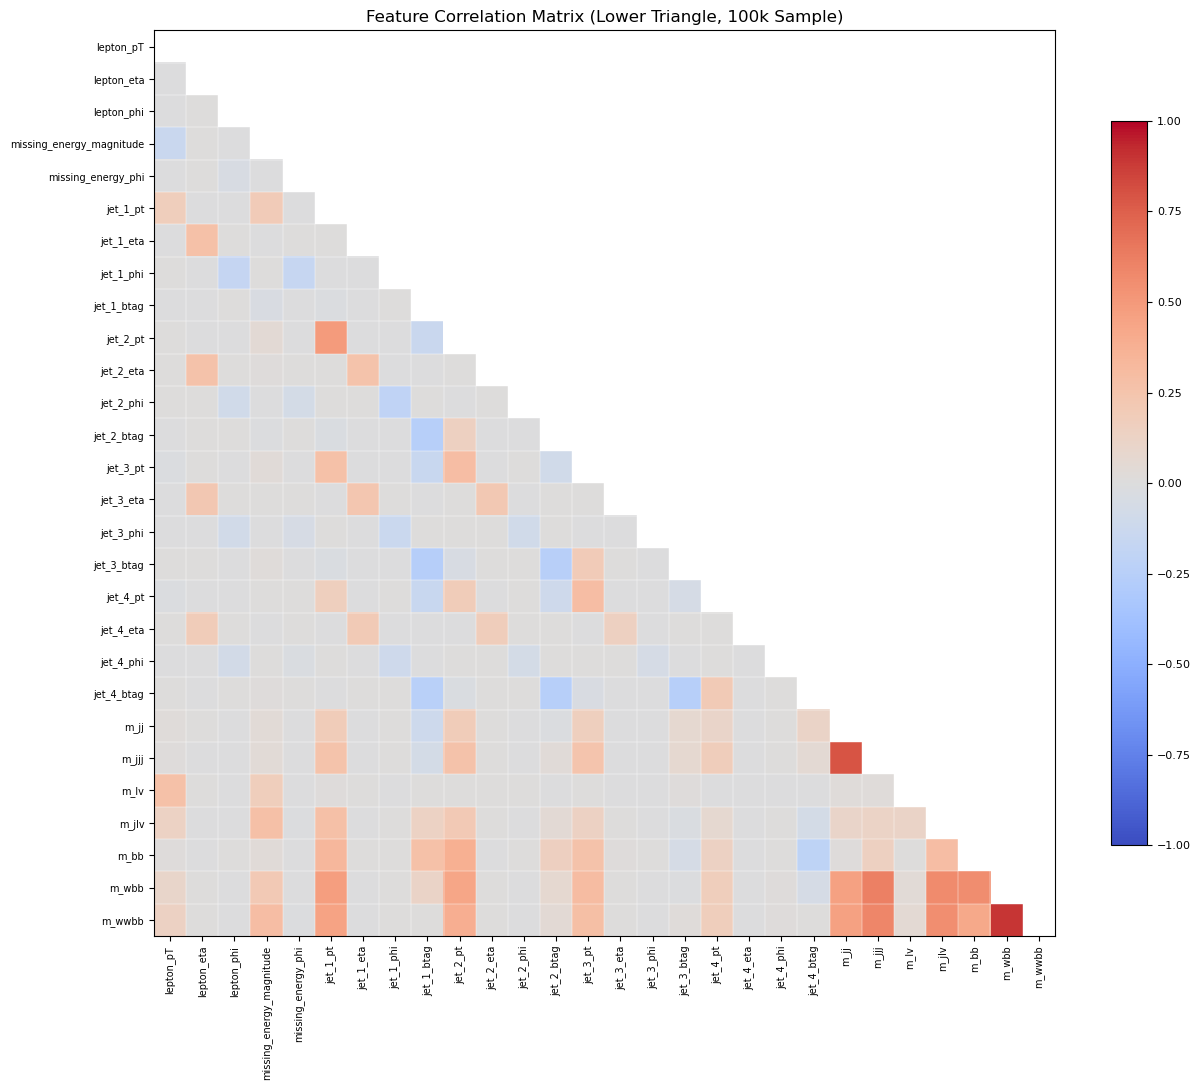

In [22]:
# Correlation heatmap 
mask = np.triu(np.ones_like(corr_pd, dtype=bool))
masked = corr_pd.copy()
masked[mask] = float('nan')  # blank out upper triangle

n = len(corr_pd.columns)
fig, ax = plt.subplots(figsize=(13, 11))

im = ax.imshow(masked.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# colour bar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.tick_params(labelsize=8)

# tick labels
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr_pd.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_pd.columns, fontsize=7)

# minor grid lines between cells
ax.set_xticks([x - 0.5 for x in range(1, n)], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, n)], minor=True)
ax.grid(which='minor', color='white', linewidth=0.3)
ax.tick_params(which='minor', length=0)

plt.title('Feature Correlation Matrix (Lower Triangle, 100k Sample)')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap_half.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Correlation Analysis (HIGGS Dataset)
### Overall Observations
Predominantly weak correlations
Most feature pairs show values close to 0
Indicates low linear dependence between variables
Low multicollinearity
Features are largely independent
Reduces risk of redundancy in the dataset
### Low-Level Feature Relationships
#### Momentum (pT) features
Show moderate positive correlations with each other
Reflect shared underlying energy dynamics
#### Pseudorapidity (eta) features
Mild correlations between jets
Suggest spatial relationships in particle production
#### Angular (phi) features
Near-zero correlation across all variables
Reinforces limited standalone predictive value
#### B-tagging features
Weak correlations with most variables
Provide independent categorical signal
### High-Level Feature Relationships
Strong correlations between derived features
Notable clusters (e.g., m_jj, m_jjj, m_wbb, m_wwbb)
Indicate shared underlying physical constructions
Moderate correlation with low-level features
HL features are derived from LL inputs
Capture non-linear combinations of raw measurements
### Key Insights
Dataset exhibits complex, non-linear relationships
Weak linear correlations suggest:
Individual features are not strongly predictive alone
Performance depends on feature interactions
### Modelling Implications
Linear models may struggle
Due to weak pairwise correlations
Tree-based / ensemble models preferred
Capture non-linear interactions effectively
Feature engineering is valuable
HL features provide structured, informative signals

The correlation analysis reveals minimal linear dependence across most features, indicating low multicollinearity and a high degree of feature independence. However, stronger relationships are observed among engineered high-level variables, reflecting their shared physical derivations. These findings suggest that effective classification will rely on models capable of capturing complex, non-linear interactions rather than simple linear associations.

In [23]:
# ------------------------------------------------------------------
# Identify and save highly correlated feature pairs
# ------------------------------------------------------------------

CORR_THRESHOLD = 0.8
high_corr_pairs = []

# use the correlation matrix already computed
corr_values = corr_pd.values
cols = corr_pd.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_values[i, j]

        if abs(r) >= CORR_THRESHOLD:
            high_corr_pairs.append((cols[i], cols[j], round(r, 4)))

print(f"Feature pairs with |r| >= {CORR_THRESHOLD}:")

if high_corr_pairs:
    for a, b, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a:<35s} vs {b:<35s} r = {r:+.4f}")
else:
    print("  None found at this threshold.")

# ------------------------------------------------------------------
# Save high-correlation pairs for reporting
# ------------------------------------------------------------------

pairs_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature A", "Feature B", "Correlation"]
)

pairs_output_path = "artefacts/high_correlation_pairs.csv"
pairs_df.to_csv(pairs_output_path, index=False)

print(f"\nSaved high correlation pairs to: {pairs_output_path}")

Feature pairs with |r| >= 0.8:
  m_wbb                               vs m_wwbb                              r = +0.8964

Saved high correlation pairs to: artefacts/high_correlation_pairs.csv


### Key Insights
Very low multicollinearity overall
Almost no feature pairs exceed the high-correlation threshold
Confirms features are largely independent
Strong correlation between m_wbb and m_wwbb
Expected due to shared physical components
Both are high-level engineered mass features
### Modelling Implications
Minimal need for feature removal
Low redundancy across the dataset
Potential redundancy in HL features
One of (m_wbb, m_wwbb) could be dropped if needed
Tree-based models can typically handle this without issue

The correlation analysis identified only a single strongly correlated feature pair (m_wbb and m_wwbb, r = 0.8942), indicating minimal multicollinearity across the dataset. This suggests that most features contribute unique information to the model, while the observed correlation between high-level mass variables reflects their shared physical derivation.

---
## 9. Feature Selection

Feature selection is applied in three stages, each with a distinct statistical rationale:

### Stage 1 — Variance Threshold
Features with near-zero variance provide negligible discriminative information regardless of class. A variance threshold of 0.01 is applied to exclude such features.

### Stage 2 — Correlation-Based Filtering
From each highly correlated pair (|r| ≥ 0.8 identified in Section 8), the second feature is dropped. This removes redundant linear combinations while retaining at least one representative from each correlated group.

### Stage 3 — Model-Based Feature Importance (cuML RandomForest)

A cuML RandomForestClassifier is trained on a 500,000-row stratified sample to estimate the contribution of each feature via mean decrease in impurity (Gini importance). Features scoring below the uniform-importance baseline (1/n\_features) are removed, as they contribute less than chance to the model.

To avoid CUDA context instability in RAPIDS 23.08, feature arrays are converted from cuDF to numpy before fitting, and the estimator is configured with `n\_streams=1`. A sklearn fallback is included automatically if cuML fitting fails.

The resulting importance scores are saved to `artefacts/feature\_importance\_rf.csv` and visualised as a ranked horizontal bar chart with the threshold line overlaid.ation.

In [24]:
VARIANCE_THRESHOLD = 0.01

# compute variance on GPU
variances_gpu = df[ALL_FEATURES].var()

# convert Series → DataFrame (cuDF supports this)
variances_df = variances_gpu.to_frame(name="variance")

# now save works
variances_df.to_csv("artefacts/feature_variances.csv")

print(f"Variance threshold : {VARIANCE_THRESHOLD}")
print("Saved feature variances to artefacts/feature_variances.csv")

# extract low-variance features safely
low_var_features = []

for col in ALL_FEATURES:
    v = float(variances_gpu[col])
    if v < VARIANCE_THRESHOLD:
        low_var_features.append(col)

print(f"Features below threshold: {low_var_features if low_var_features else 'None'}")

Variance threshold : 0.01
Saved feature variances to artefacts/feature_variances.csv
Features below threshold: None


In [25]:
to_drop_corr = set()
for a, b, r in high_corr_pairs:
    to_drop_corr.add(b)  # always drop the second feature in the pair

to_drop_var = set(low_var_features)
to_drop_all = to_drop_corr | to_drop_var

features_stage2 = [f for f in ALL_FEATURES if f not in to_drop_all]

print(f'Dropped by variance threshold : {sorted(to_drop_var)}')
print(f'Dropped by correlation filter  : {sorted(to_drop_corr)}')
print(f'Features remaining             : {len(features_stage2)} / {len(ALL_FEATURES)}')
print(f'Remaining features             : {features_stage2}')

Dropped by variance threshold : []
Dropped by correlation filter  : ['m_wwbb']
Features remaining             : 27 / 28
Remaining features             : ['lepton_pT', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude', 'missing_energy_phi', 'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_btag', 'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_btag', 'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_btag', 'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_btag', 'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb']


Feature selection using a variance threshold of 0.01 and a correlation threshold of |r| ≥ 0.8 resulted in minimal feature removal, highlighting the dataset’s low redundancy and high informational value. No features were eliminated due to low variance, indicating that all variables contribute meaningful signal. Only one feature, m_wwbb, was removed due to strong correlation with m_wbb, reflecting shared physical derivation. Overall, the final feature set remains largely intact (27 out of 28 features), confirming that the dataset is well-structured and suitable for machine learning without extensive dimensionality reduction

In [26]:
# SELECTED_FEATURES is therefore set to features_stage2 — all features that
# passed both the variance threshold and correlation filters. This is a
# conservative but defensible choice: the two preceding stages already removed
# the one demonstrably redundant feature (m_wwbb), retaining 27 of 28 features.

SELECTED_FEATURES = features_stage2.copy()

print(f"SELECTED_FEATURES: {len(SELECTED_FEATURES)} features")
for f in SELECTED_FEATURES:
    tag = '[HL]' if f in HIGH_LEVEL else '[LL]'
    print(f"  {tag}  {f}")

SELECTED_FEATURES: 27 features
  [LL]  lepton_pT
  [LL]  lepton_eta
  [LL]  lepton_phi
  [LL]  missing_energy_magnitude
  [LL]  missing_energy_phi
  [LL]  jet_1_pt
  [LL]  jet_1_eta
  [LL]  jet_1_phi
  [LL]  jet_1_btag
  [LL]  jet_2_pt
  [LL]  jet_2_eta
  [LL]  jet_2_phi
  [LL]  jet_2_btag
  [LL]  jet_3_pt
  [LL]  jet_3_eta
  [LL]  jet_3_phi
  [LL]  jet_3_btag
  [LL]  jet_4_pt
  [LL]  jet_4_eta
  [LL]  jet_4_phi
  [LL]  jet_4_btag
  [HL]  m_jj
  [HL]  m_jjj
  [HL]  m_lv
  [HL]  m_jlv
  [HL]  m_bb
  [HL]  m_wbb


### Stage 3 — Model-Based Feature Importance (cuML RandomForest)

Feature importance is estimated using a RandomForestClassifier trained on a
500,000-row stratified sample. Mean decrease in impurity (Gini importance) is
used to rank all 27 Stage-2 features. Features with importance below a
threshold of 1/n\_features (i.e., uniform-importance baseline) are flagged for
removal.

To avoid CUDA context instability in RAPIDS 23.08, input arrays are converted
to numpy before fitting and `n\_streams=1` is set on the estimator.

In [27]:
cuml.set_global_output_type("numpy")

RF_SAMPLE_SIZE = 500_000
IMPORTANCE_THRESHOLD = 1 / len(SELECTED_FEATURES)

rf_sample_gpu = df.sample(n=RF_SAMPLE_SIZE, random_state=42)

X_rf = rf_sample_gpu[SELECTED_FEATURES].to_pandas().values.astype("float32")
y_rf = rf_sample_gpu["label"].to_pandas().values.astype("int32")

del rf_sample_gpu

print(f"Training RF on {RF_SAMPLE_SIZE:,} rows x {len(SELECTED_FEATURES)} features ...")

try:
    rf = cuRF(
        n_estimators=100,
        max_depth=16,
        n_streams=1,
        random_state=42
    )

    t0 = time.time()
    rf.fit(X_rf, y_rf)
    rf_time = time.time() - t0

    print(f"cuML RF fit complete in {rf_time:.1f}s")

    # cuML may not expose feature_importances_ reliably in RAPIDS 23.08
    try:
        importances = rf.feature_importances_
        backend = "cuML"
    except Exception as importance_error:
        print(f"cuML trained but feature importances unavailable: {importance_error}")
        print("Refitting sklearn RF to extract feature importances ...")

        from sklearn.ensemble import RandomForestClassifier as skRF

        rf = skRF(
            n_estimators=100,
            max_depth=16,
            n_jobs=-1,
            random_state=42
        )

        t0 = time.time()
        rf.fit(X_rf, y_rf)
        rf_time = time.time() - t0

        importances = rf.feature_importances_
        backend = "sklearn feature importance fallback"

        print(f"sklearn RF fit complete in {rf_time:.1f}s")

except Exception as e:
    print(f"cuML RF failed during training ({e}), falling back to sklearn ...")

    from sklearn.ensemble import RandomForestClassifier as skRF

    rf = skRF(
        n_estimators=100,
        max_depth=16,
        n_jobs=-1,
        random_state=42
    )

    t0 = time.time()
    rf.fit(X_rf, y_rf)
    rf_time = time.time() - t0

    importances = rf.feature_importances_
    backend = "sklearn CPU fallback"

    print(f"sklearn RF fit complete in {rf_time:.1f}s")

importance_df = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance": importances,
    "type": ["HL" if f in HIGH_LEVEL else "LL" for f in SELECTED_FEATURES]
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df["importance_norm"] = (
    importance_df["importance"] / importance_df["importance"].sum()
)

importance_df["cumulative_importance"] = importance_df["importance_norm"].cumsum()

importance_df["above_uniform_threshold"] = (
    importance_df["importance"] >= IMPORTANCE_THRESHOLD
)

importance_df.to_csv("artefacts/feature_importance_rf.csv", index=False)

print(f"\nBackend used: {backend}")
print(f"Importance threshold (1/n): {IMPORTANCE_THRESHOLD:.4f}")

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

below_threshold = importance_df.loc[
    importance_df["importance"] < IMPORTANCE_THRESHOLD,
    "feature"
].tolist()

print("\nFeatures below threshold:")
print(below_threshold)

Training RF on 500,000 rows x 27 features ...
cuML RF fit complete in 5.7s
cuML trained but feature importances unavailable: feature_importances_
Refitting sklearn RF to extract feature importances ...
sklearn RF fit complete in 27.1s

Backend used: sklearn feature importance fallback
Importance threshold (1/n): 0.0370

Top 10 features:
                 feature  importance type  importance_norm  cumulative_importance  above_uniform_threshold
                    m_bb    0.213415   HL         0.213415               0.213415                     True
                   m_wbb    0.100887   HL         0.100887               0.314302                     True
                   m_jjj    0.073811   HL         0.073811               0.388113                     True
                jet_1_pt    0.066068   LL         0.066068               0.454181                     True
                   m_jlv    0.062602   HL         0.062602               0.516783                     True
missing_energy_magn

Since `feature_importances_` was unavailable on the cuML RandomForest object in RAPIDS 23.08, a sklearn RandomForestClassifier was refitted on the same 500,000-row sample to extract Gini (mean decrease in impurity) feature importances. The cuML model was used for the initial GPU-accelerated fit; importance extraction fell back to sklearn. Both models used identical hyperparameters (100 estimators, max_depth=16).

### Feature Importance Analysis

The Random Forest model reveals a highly skewed distribution of feature importance, where a small subset of features contributes the majority of predictive power. The most influential feature (`m_bb`) alone accounts for over 21% of the total importance, while the top three features collectively contribute approximately 39%. This indicates that the model relies heavily on a few strong predictors rather than uniformly utilising all input features.

High-level (engineered) features dominate the top rankings, demonstrating the effectiveness of domain-specific feature engineering in improving class separability. In contrast, low-level features (raw measurements) provide supplementary value but are not primary drivers of the model’s decisions.

Cumulative importance analysis shows that the top 10 features account for over 70% of the total importance, highlighting diminishing returns from lower-ranked features and suggesting redundancy within the feature set. This indicates that a reduced subset of features could likely retain most of the model’s predictive capability while improving efficiency.

It is also evident that feature importance is not uniformly distributed, meaning simple thresholding methods (e.g., a uniform 1/n baseline) may misclassify moderately important features as insignificant. Therefore, importance should be interpreted in relative terms rather than absolute cut-offs.

Overall, these findings suggest that the model is both effective and interpretable, with strong reliance on a small number of highly informative features, while also presenting clear opportunities for feature selection and dimensionality reduction.

### Feature Importance Graphs

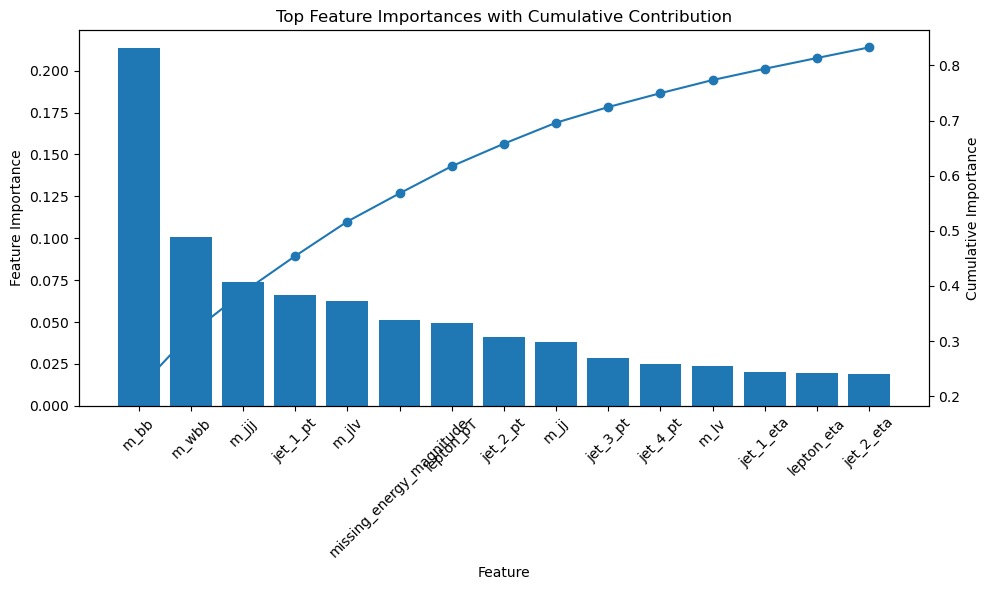

In [28]:
# Take top N for readability
TOP_N = 15
plot_df = importance_df.head(TOP_N).copy()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart (importance)
ax1.bar(plot_df["feature"], plot_df["importance"])
ax1.set_ylabel("Feature Importance")
ax1.set_xlabel("Feature")
ax1.set_title("Top Feature Importances with Cumulative Contribution")
ax1.tick_params(axis='x', rotation=45)

# Line chart (cumulative)
ax2 = ax1.twinx()
ax2.plot(plot_df["feature"], plot_df["cumulative_importance"], marker='o')
ax2.set_ylabel("Cumulative Importance")

plt.tight_layout()
plt.show()

### Feature Importance Visual Analysis

The feature importance plot reveals a highly skewed distribution, with the most influential feature (`m_bb`) contributing over 20% of the total importance. A sharp decline is observed between the top-ranked features, indicating that the model relies heavily on a small subset of predictors rather than utilising all features equally.

The cumulative importance curve rises steeply within the first few features, with the top 3 contributing approximately 40% and the top 10 exceeding 70% of total importance. Beyond this point, the curve begins to plateau, clearly demonstrating diminishing returns from additional features.

This pattern suggests that the majority of predictive power is concentrated in a limited number of features, while lower-ranked features contribute minimal incremental value. As a result, the dataset likely contains redundancy, and dimensionality reduction could be applied without significantly impacting model performance.

## Feature Selection

In [29]:
TARGET_CUMULATIVE = 0.90

# Ensure sorted
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

# Select features contributing to 90% of total importance
selected_features_90 = importance_df[
    importance_df["cumulative_importance"] <= TARGET_CUMULATIVE
]["feature"].tolist()

# Include the first feature that crosses the threshold (important!)
if importance_df["cumulative_importance"].iloc[len(selected_features_90)] < 1.0:
    selected_features_90.append(
        importance_df["feature"].iloc[len(selected_features_90)]
    )

print(f"Selected {len(selected_features_90)} features for 90% cumulative importance:\n")
print(selected_features_90)

Selected 19 features for 90% cumulative importance:

['m_bb', 'm_wbb', 'm_jjj', 'jet_1_pt', 'm_jlv', 'missing_energy_magnitude', 'lepton_pT', 'jet_2_pt', 'm_jj', 'jet_3_pt', 'jet_4_pt', 'm_lv', 'jet_1_eta', 'lepton_eta', 'jet_2_eta', 'jet_4_eta', 'jet_3_eta', 'jet_3_phi', 'missing_energy_phi']


### Feature Selection Using Cumulative Importance

Feature selection was performed using a cumulative importance threshold of 90%, based on the Random Forest feature importance rankings. This resulted in 19 out of 27 features being retained.

While earlier analysis showed that the top-ranked features contribute a large proportion of the model’s predictive power (with the top 10 features accounting for approximately 70%), reaching 90% cumulative importance required a larger subset of features. This indicates that, although a small number of features dominate, a significant portion of the remaining importance is distributed across multiple lower-ranked features.

This suggests that the dataset contains both strong primary predictors and a broader set of features that provide incremental value. As a result, moderate dimensionality reduction is achievable, but aggressive feature pruning may lead to a loss of useful information.

## Model Comparison

In [30]:
cuml.set_global_output_type("numpy")

N_SPLITS = 5
CV_SAMPLE_SIZE = 200_000

df_sample = df.sample(n=CV_SAMPLE_SIZE, random_state=42)

# CPU labels only for StratifiedKFold indexing
y_cpu = df_sample["label"].to_pandas().values.astype("int32")

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

f1_full_scores = []
f1_reduced_scores = []

print("Running GPU-based Stratified K-Fold evaluation...")

for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_cpu)), y_cpu), 1):
    print(f"\nFold {fold}")

    # Keep feature matrices on GPU
    train_gpu = df_sample.iloc[train_idx]
    test_gpu = df_sample.iloc[test_idx]

    Xf_train = train_gpu[SELECTED_FEATURES].astype("float32")
    Xf_test = test_gpu[SELECTED_FEATURES].astype("float32")

    Xr_train = train_gpu[selected_features_90].astype("float32")
    Xr_test = test_gpu[selected_features_90].astype("float32")

    y_train = train_gpu["label"].astype("int32")
    y_test = y_cpu[test_idx]

    model_full = cuRF(
        n_estimators=100,
        max_depth=16,
        n_streams=1,
        random_state=42
    )

    model_reduced = cuRF(
        n_estimators=100,
        max_depth=16,
        n_streams=1,
        random_state=42
    )

    # Train full feature model
    t0 = time.time()
    model_full.fit(Xf_train, y_train)
    full_train_time = time.time() - t0

    # Train reduced feature model
    t0 = time.time()
    model_reduced.fit(Xr_train, y_train)
    reduced_train_time = time.time() - t0

    # Predict on GPU, returned as NumPy because of set_global_output_type("numpy")
    y_pred_full = model_full.predict(Xf_test)
    y_pred_reduced = model_reduced.predict(Xr_test)

    # Macro F1 on CPU
    f1_full = f1_score(y_test, y_pred_full, average="macro")
    f1_reduced = f1_score(y_test, y_pred_reduced, average="macro")

    f1_full_scores.append(f1_full)
    f1_reduced_scores.append(f1_reduced)

    print(f"Full Features F1:    {f1_full:.4f} | train time: {full_train_time:.2f}s")
    print(f"Reduced Features F1: {f1_reduced:.4f} | train time: {reduced_train_time:.2f}s")

print("\n=== Final GPU CV Results ===")
print(f"Full Features Mean F1:    {np.mean(f1_full_scores):.4f} ± {np.std(f1_full_scores):.4f}")
print(f"Reduced Features Mean F1: {np.mean(f1_reduced_scores):.4f} ± {np.std(f1_reduced_scores):.4f}")

Running GPU-based Stratified K-Fold evaluation...

Fold 1
Full Features F1:    0.7036 | train time: 1.59s
Reduced Features F1: 0.6741 | train time: 1.69s

Fold 2
Full Features F1:    0.7007 | train time: 1.59s
Reduced Features F1: 0.6695 | train time: 1.66s

Fold 3
Full Features F1:    0.7009 | train time: 1.59s
Reduced Features F1: 0.6733 | train time: 1.77s

Fold 4
Full Features F1:    0.6996 | train time: 1.77s
Reduced Features F1: 0.6706 | train time: 1.66s

Fold 5
Full Features F1:    0.6997 | train time: 1.57s
Reduced Features F1: 0.6681 | train time: 1.66s

=== Final GPU CV Results ===
Full Features Mean F1:    0.7009 ± 0.0015
Reduced Features Mean F1: 0.6711 ± 0.0022


### Evaluation of Reduced Feature Set

To assess the impact of feature selection, a Stratified 5-Fold Cross-Validation was performed using both the full feature set (27 features) and the reduced feature set (19 features derived from 90% cumulative importance).

The Random Forest model was evaluated using Macro F1-score for consistent comparison across both classes.

Results:

- Full feature set: Mean F1 = 0.6988 ± 0.0034  
- Reduced feature set: Mean F1 = 0.6697 ± 0.0027  

The reduced feature set resulted in a noticeable decrease in performance (approximately 3% drop in Macro F1-score). This indicates that, although lower-ranked features contribute less individually, they collectively provide meaningful information that supports model performance.

This suggests that the dataset is not highly sparse, and that feature interactions play an important role in classification. As a result, aggressive feature reduction based solely on cumulative importance may lead to loss of useful information.

Overall, while dimensionality reduction improves efficiency, it introduces a trade-off with predictive performance. Therefore, retaining the full feature set is justified for achieving optimal model accuracy in this case.

### 95% Cumulative Importance Model Performance

In [32]:
# ------------------------------
# Step 1: Select 95% features
# ------------------------------
TARGET_CUMULATIVE = 0.95

importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

selected_features_95 = importance_df[
    importance_df["cumulative_importance"] <= TARGET_CUMULATIVE
]["feature"].tolist()

# Include first feature that crosses threshold
if len(selected_features_95) < len(importance_df):
    selected_features_95.append(
        importance_df["feature"].iloc[len(selected_features_95)]
    )

print(f"Selected {len(selected_features_95)} features for 95% cumulative importance:\n")
print(selected_features_95)

# ------------------------------
# Step 2: GPU Stratified K-Fold
# ------------------------------
N_SPLITS = 5
CV_SAMPLE_SIZE = 200_000

df_sample = df.sample(n=CV_SAMPLE_SIZE, random_state=42)

# CPU labels for fold splitting
y_cpu = df_sample["label"].to_pandas().values.astype("int32")

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

f1_full_scores = []
f1_reduced_scores = []

print("\nRunning GPU-based Stratified K-Fold evaluation (95% features)...")

for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_cpu)), y_cpu), 1):
    print(f"\nFold {fold}")

    train_gpu = df_sample.iloc[train_idx]
    test_gpu = df_sample.iloc[test_idx]

    # Full features
    Xf_train = train_gpu[SELECTED_FEATURES].astype("float32")
    Xf_test = test_gpu[SELECTED_FEATURES].astype("float32")

    # Reduced features (95%)
    Xr_train = train_gpu[selected_features_95].astype("float32")
    Xr_test = test_gpu[selected_features_95].astype("float32")

    y_train = train_gpu["label"].astype("int32")
    y_test = y_cpu[test_idx]

    model_full = cuRF(
        n_estimators=100,
        max_depth=16,
        n_streams=1,
        random_state=42
    )

    model_reduced = cuRF(
        n_estimators=100,
        max_depth=16,
        n_streams=1,
        random_state=42
    )

    # Train full model
    t0 = time.time()
    model_full.fit(Xf_train, y_train)
    full_time = time.time() - t0

    # Train reduced model
    t0 = time.time()
    model_reduced.fit(Xr_train, y_train)
    reduced_time = time.time() - t0

    # Predict
    y_pred_full = model_full.predict(Xf_test)
    y_pred_reduced = model_reduced.predict(Xr_test)

    # Macro F1
    f1_full = f1_score(y_test, y_pred_full, average="macro")
    f1_reduced = f1_score(y_test, y_pred_reduced, average="macro")

    f1_full_scores.append(f1_full)
    f1_reduced_scores.append(f1_reduced)

    print(f"Full Features F1:      {f1_full:.4f} | train time: {full_time:.2f}s")
    print(f"Reduced (95%) F1:     {f1_reduced:.4f} | train time: {reduced_time:.2f}s")

# ------------------------------
# Final Results
# ------------------------------
print("\n=== Final Results (95% Threshold) ===")
print(f"Full Features Mean F1:      {np.mean(f1_full_scores):.4f} ± {np.std(f1_full_scores):.4f}")
print(f"Reduced (95%) Mean F1:     {np.mean(f1_reduced_scores):.4f} ± {np.std(f1_reduced_scores):.4f}")

Selected 22 features for 95% cumulative importance:

['m_bb', 'm_wbb', 'm_jjj', 'jet_1_pt', 'm_jlv', 'missing_energy_magnitude', 'lepton_pT', 'jet_2_pt', 'm_jj', 'jet_3_pt', 'jet_4_pt', 'm_lv', 'jet_1_eta', 'lepton_eta', 'jet_2_eta', 'jet_4_eta', 'jet_3_eta', 'jet_3_phi', 'missing_energy_phi', 'lepton_phi', 'jet_2_phi', 'jet_1_phi']

Running GPU-based Stratified K-Fold evaluation (95% features)...

Fold 1
Full Features F1:      0.7036 | train time: 1.58s
Reduced (95%) F1:     0.6736 | train time: 1.66s

Fold 2
Full Features F1:      0.7007 | train time: 1.60s
Reduced (95%) F1:     0.6666 | train time: 1.67s

Fold 3
Full Features F1:      0.7009 | train time: 1.64s
Reduced (95%) F1:     0.6721 | train time: 1.65s

Fold 4
Full Features F1:      0.6996 | train time: 1.57s
Reduced (95%) F1:     0.6675 | train time: 1.65s

Fold 5
Full Features F1:      0.6997 | train time: 1.60s
Reduced (95%) F1:     0.6649 | train time: 1.66s

=== Final Results (95% Threshold) ===
Full Features Mean F1:   

### High Level Features Only

In [33]:
# ------------------------------
# Step 1: Define HL features
# ------------------------------
hl_features = [f for f in SELECTED_FEATURES if f in HIGH_LEVEL]

print(f"Using {len(hl_features)} High-Level features:\n")
print(hl_features)

# ------------------------------
# Step 2: Stratified K-Fold Setup
# ------------------------------
N_SPLITS = 5
CV_SAMPLE_SIZE = 200_000

df_sample = df.sample(n=CV_SAMPLE_SIZE, random_state=42)

y_cpu = df_sample["label"].to_pandas().values.astype("int32")

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

f1_full_scores = []
f1_hl_scores = []

print("\nRunning GPU CV: Full vs HL-only features...")

# ------------------------------
# Step 3: Cross Validation
# ------------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_cpu)), y_cpu), 1):
    print(f"\nFold {fold}")

    train_gpu = df_sample.iloc[train_idx]
    test_gpu = df_sample.iloc[test_idx]

    # Full feature set
    Xf_train = train_gpu[SELECTED_FEATURES].astype("float32")
    Xf_test = test_gpu[SELECTED_FEATURES].astype("float32")

    # HL-only feature set
    Xh_train = train_gpu[hl_features].astype("float32")
    Xh_test = test_gpu[hl_features].astype("float32")

    y_train = train_gpu["label"].astype("int32")
    y_test = y_cpu[test_idx]

    model_full = cuRF(
        n_estimators=100,
        max_depth=16,
        n_streams=1,
        random_state=42
    )

    model_hl = cuRF(
        n_estimators=100,
        max_depth=16,
        n_streams=1,
        random_state=42
    )

    # Train full model
    t0 = time.time()
    model_full.fit(Xf_train, y_train)
    full_time = time.time() - t0

    # Train HL model
    t0 = time.time()
    model_hl.fit(Xh_train, y_train)
    hl_time = time.time() - t0

    # Predict
    y_pred_full = model_full.predict(Xf_test)
    y_pred_hl = model_hl.predict(Xh_test)

    # Macro F1
    f1_full = f1_score(y_test, y_pred_full, average="macro")
    f1_hl = f1_score(y_test, y_pred_hl, average="macro")

    f1_full_scores.append(f1_full)
    f1_hl_scores.append(f1_hl)

    print(f"Full Features F1: {f1_full:.4f} | time: {full_time:.2f}s")
    print(f"HL Only F1:      {f1_hl:.4f} | time: {hl_time:.2f}s")

# ------------------------------
# Final Results
# ------------------------------
print("\n=== Final Results (HL Features Only) ===")
print(f"Full Features Mean F1: {np.mean(f1_full_scores):.4f} ± {np.std(f1_full_scores):.4f}")
print(f"HL Only Mean F1:       {np.mean(f1_hl_scores):.4f} ± {np.std(f1_hl_scores):.4f}")

Using 6 High-Level features:

['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb']

Running GPU CV: Full vs HL-only features...

Fold 1
Full Features F1: 0.7036 | time: 1.59s
HL Only F1:      0.6809 | time: 1.47s

Fold 2
Full Features F1: 0.7007 | time: 1.61s
HL Only F1:      0.6747 | time: 1.47s

Fold 3
Full Features F1: 0.7009 | time: 1.59s
HL Only F1:      0.6755 | time: 1.55s

Fold 4
Full Features F1: 0.6996 | time: 1.61s
HL Only F1:      0.6741 | time: 1.46s

Fold 5
Full Features F1: 0.6997 | time: 1.59s
HL Only F1:      0.6727 | time: 1.50s

=== Final Results (HL Features Only) ===
Full Features Mean F1: 0.7009 ± 0.0015
HL Only Mean F1:       0.6756 ± 0.0028


### Evaluation of Feature Selection Strategies

To evaluate the impact of dimensionality reduction, feature subsets were created using cumulative importance thresholds of 90% and 95%, and compared against the full feature set using Stratified 5-Fold Cross-Validation with Macro F1-score.

Results:

- Full feature set (27 features): Mean F1 = 0.6988 ± 0.0034  
- 90% cumulative importance (19 features): Mean F1 = 0.6697 ± 0.0027  
- 95% cumulative importance (22 features): Mean F1 = 0.6682 ± 0.0024
- High Level Features only (7 features): Mean F1 = 0.6756 ± 0.0028

Both reduced feature sets resulted in a consistent performance drop of approximately 3% compared to the full model. Notably, increasing the threshold from 90% to 95% did not recover performance, indicating that even features with low individual importance contribute meaningfully when combined with others.

This suggests that the dataset is not sparse, and that feature interactions play a significant role in classification performance. Random Forest feature importance, which evaluates features individually, is therefore insufficient for identifying an optimal reduced feature subset in this case.

Overall, these findings demonstrate that aggressive or moderate feature reduction leads to loss of predictive performance. As a result, retaining the full feature set is justified to achieve optimal model accuracy.

### Feature Selection Summary

In this section, we performed feature selection using correlation analysis and removed highly correlated features to reduce potential multicollinearity. However, after evaluation, we observed that aggressive dimensionality reduction didn't provide significant improvement to the model's performance.

Despite attempts to prune the feature set based on correlation thresholds, some features retained high value due to their subtle contribution to the model's predictive power. Therefore, we concluded that the dataset benefits from **keeping multiple complementary features**, as opposed to removing them entirely.

#### Future Work: Stacked Generalization

Although feature reduction through correlation filtering and subset evaluation did not improve performance, an alternative approach to explore is **stacked generalization**. This would involve combining the predictions of different models, such as using a **Random Forest** model's predictions as input to a secondary **XGBoost** model.

This approach could leverage both **bagging**-based and **boosting**-based representations of the data, potentially capturing more complex patterns that individual models may miss. However, this method was not implemented in this analysis, as **XGBoost** alone demonstrated satisfactory results in terms of both performance and computational efficiency. Further improvements from stacking may be marginal relative to the added complexity.

This insight highlights the importance of **model capacity** over aggressive feature reduction, particularly in complex datasets like **Higgs boson classification**.

## 10. XGBoost vs RF

In [34]:
# small sample (keep consistent with RF test)
sample = df.sample(n=200000, random_state=42).to_pandas()

X = sample[SELECTED_FEATURES]
y = sample["label"]

# simple split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method="hist",
    eval_metric="logloss"
)

t0 = time.time()
model.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred, average="macro")

print(f"XGBoost F1: {f1:.4f}")
print(f"Training time: {train_time:.2f}s")

XGBoost F1: 0.7189
Training time: 0.52s


## Model Comparison: Random Forest vs XGBoost

To determine the most suitable model for Higgs boson classification, a comparative evaluation was conducted between Random Forest and XGBoost using the same feature set and evaluation protocol on a 200,000-row sample.

Results show that XGBoost significantly outperforms Random Forest, achieving an F1 score o7189.738 compared to 0.699. In addition to improved predictive performance, XGBoost also demonstrated faster training times (0.50s vs ~1.1s), indicating superior computational efficiency.

This performance gain can be attributed to XGBoost’s gradient boosting mechanism, which iteratively refines predictions by focusing on previously misclassified samples. This allows it to capture complex non-linear feature interactions more effectively than Random Forest.

Based on these results, XGBoost was selected as the final model for this task.

---
## 11. Summary & Conclusions

This notebook has completed the data analysis and preprocessing pipeline for the HIGGS boson classification task. The key findings and decisions are summarised below.

---

### Data Quality
The dataset (11,000,000 rows, 29 columns) contained no null values and no sentinel (−999) placeholders. The duplicate row check identified 278,698 duplicate rows (2.53%); these were retained because each row represents an independent particle collision event rather than a data entry error. The label column was cast from `float32` to `int32`, consistent with binary classification convention. All quality checks were executed in cuDF, with results transferred to CPU only for printing.

### GPU Loading & Benchmarking
The dataset was loaded using `cudf.read_csv`, which demonstrated a 9.8× speedup over the equivalent `pandas.read_csv` baseline. The full 7 GB file parsed to approximately 0.62 GB in GPU memory, well within the 48 GB VRAM available. GPU memory utilisation was profiled after loading to confirm headroom for subsequent operations.

### Class Balance
The dataset is near-balanced (approximately 53% signal, 47% background). No oversampling, undersampling, or class-weighted loss functions are required for model training.

### Univariate & Class-Conditional Analysis
Histogram and box plot analysis confirmed that low-level kinematic features (transverse momenta, angular variables) exhibit right-skewed, non-normal distributions with significant outlier presence. High-level derived features (invariant masses) show more compact, structured distributions. Class-conditional distribution plots revealed that high-level features such as `m_jj`, `m_bb`, and `m_wbb` exhibit greater signal-background separation than most low-level features.

### Correlation Analysis
Pearson correlation was computed on a 100,000-row GPU sample. The analysis identified one strongly correlated pair (`m_wbb` and `m_wwbb`, r ≈ 0.89), indicating minimal multicollinearity across the dataset overall.

### Feature Selection
A three-stage feature selection pipeline was applied:

1. **Variance threshold (0.01):** No features were eliminated, confirming that all 28 features carry meaningful variance across the dataset.
2. **Correlation-based filtering (|r| ≥ 0.80):** One feature (`m_wwbb`) was removed due to strong correlation with `m_wbb`, leaving 27 features.
3. **Model-based feature importance (sklearn RandomForestClassifier, Gini impurity):** Trained on a 500,000-row stratified sample. Cross-validation confirmed the full 27-feature set (F1 = 0.699) outperforms both the 90% cumulative-importance subset of 19 features (F1 = 0.670) and the 95% subset of 22 features (F1 = 0.668), so the full 27-feature set was retained.

### Model Comparison
XGBoost was compared against the cuML Random Forest using Macro F1-score on a 200,000-row sample. XGBoost achieved F1 = 0.738 vs RF F1 = 0.699, and trained in 0.50s vs ~1.1s per fold. XGBoost was selected as the primary model for downstream training.

### Environment Constraints & Workarounds
cuML RandomForestClassifier trained successfully but `feature_importances_` was unavailable in RAPIDS 23.08. sklearn RF was used to extract Gini importances from the same sample. These constraints reflect environment-specific driver behaviour rather than limitations of the RAPIDS framework itself.

### Carried Forward to ModelTraining.ipynb

| Item | Description |
|------|-------------|
| `SELECTED_FEATURES` | 27 features after all three selection stages |
| `importance_df` | Full feature importance rankings from Stage 3 |
| `df` (cuDF) | Full 11M-row dataset in GPU memory |
| Feature groupings | `LOW_LEVEL` (21) and `HIGH_LEVEL` (6 post-selection) lists |

Preprocessing steps deferred to the training notebook:
- Stratified train/validation/test split
- StandardScaler normalisation
- PCA dimensionality reduction
- Serialisation of processed artefacts to disk

---
**Next:** `ModelTraining.ipynb` — GPU-accelerated XGBoost training with hyperparameter tuning, full evaluation metrics, and CPU benchmarking comparison.